# Landsat green cover and precipitation analysis

This cleaned version keeps the Landsat analysis only. Sentinel-specific loading, processing, plots, labels, and comparisons have been removed. The later analysis cells have also been reformatted to match the compact style used near the start of the original notebook.

In [28]:
import pathlib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.stats import norm, pearsonr, spearmanr
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

#settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)
data_folder = pathlib.Path(".")
station_pattern = "dados_A*_M_*.csv"
if not any(data_folder.glob(station_pattern)) and pathlib.Path("/mnt/data").exists():
    data_folder = pathlib.Path("/mnt/data")

green_file = data_folder / "monthly_green_clean.csv"
min_stations_for_average = 1
remove_precipitation_outliers = False
precipitation_iqr_multiplier = 4.0
min_valid_pct = 10.0
min_pred_pct = 10.0
require_use_flag = True
remove_bad_image_flags = True
plot_start_date = pd.Timestamp("2008-01-01")
complete_year_months = 12
month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec",]

print(f"Data folder: {data_folder.resolve()}")
print(f"Landsat: {green_file.name}")

Data folder: /Users/aishling/Desktop/Project/Vidoe_processing
Landsat: monthly_green_clean.csv


In [29]:
#functions
def parse_station_metadata(file_path, metadata_lines=9):
    metadata = {}
    with open(file_path, "r", encoding="utf-8-sig", errors="replace") as handle:
        for _ in range(metadata_lines):
            line = handle.readline().strip()
            if ":" in line:
                key, value = line.split(":", 1)
                metadata[key.strip()] = value.strip()
    return metadata

def upper_extreme_iqr_flag(series, multiplier=3.0):
    values = pd.to_numeric(series, errors="coerce")
    valid = values.dropna()
    if valid.empty:
        return pd.Series(False, index=series.index, dtype=bool), np.nan
    q1 = valid.quantile(0.25)
    q3 = valid.quantile(0.75)
    upper_fence = q3 + multiplier * (q3 - q1)
    return (values > upper_fence).fillna(False), upper_fence

def load_monthly_station(file_path, remove_outliers=False, iqr_multiplier=3.0):
    file_path = pathlib.Path(file_path)
    metadata = parse_station_metadata(file_path)
    station_code = metadata.get(
        "Codigo Estacao",
        file_path.stem.split("_")[1] if "_" in file_path.stem else file_path.stem,)
    station_name = metadata.get("Nome", station_code)

    raw = pd.read_csv(
        file_path,
        sep=";",
        skiprows=10,
        usecols=[0, 1],
        na_values=["null", "NULL", "", "NA", "NaN"],)
    raw.columns = ["date", "precip_mm"]
    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    raw["date"] = raw["date"].dt.to_period("M").dt.to_timestamp()
    raw["precip_mm"] = pd.to_numeric(raw["precip_mm"], errors="coerce")
    raw["invalid_date"] = raw["date"].isna()
    raw["negative_precip"] = raw["precip_mm"] < 0
    raw.loc[raw["negative_precip"], "precip_mm"] = np.nan

    duplicate_rows = int(raw.duplicated(subset="date", keep=False).sum())

    monthly = (raw.dropna(subset=["date"]).groupby("date", as_index=False)
        .agg(precip_mm=("precip_mm", "mean")).sort_values("date"))

    monthly["potential_outlier"], upper_fence = upper_extreme_iqr_flag(
        monthly["precip_mm"],multiplier=iqr_multiplier,)
    outlier_count = int(monthly["potential_outlier"].sum())

    if remove_outliers:
        monthly.loc[monthly["potential_outlier"], "precip_mm"] = np.nan

    report = {"station_code": station_code,
        "station_name": station_name,
        "latitude": pd.to_numeric(metadata.get("Latitude"), errors="coerce"),
        "longitude": pd.to_numeric(metadata.get("Longitude"), errors="coerce"),
        "altitude_m": pd.to_numeric(metadata.get("Altitude"), errors="coerce"),
        "source_rows": len(raw),
        "invalid_dates": int(raw["invalid_date"].sum()),
        "negative_values_removed": int(raw["negative_precip"].sum()),
        "duplicate_rows": duplicate_rows,
        "valid_months": int(monthly["precip_mm"].notna().sum()),
        "missing_months_in_file": int(monthly["precip_mm"].isna().sum()),
        "potential_outliers": outlier_count,
        "upper_extreme_fence_mm": upper_fence,}

    precip_column = f"precip_{station_code}_mm"
    monthly = monthly[["date", "precip_mm"]].rename(
        columns={"precip_mm": precip_column})
    return monthly.set_index("date"), report

def parse_bool_series(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype("boolean")

    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True,
                "1": True,
                "yes": True,
                "y": True,
                "false": False,
                "0": False,
                "no": False,
                "n": False,
                "nan": pd.NA,
                "none": pd.NA,
                "": pd.NA,}).astype("boolean"))

def load_green_cover(
    file_path,
    min_valid=10.0,
    min_pred=10.0,
    require_use=True,
    remove_bad_flags=True,):
    file_path = pathlib.Path(file_path)
    raw = pd.read_csv(file_path)
    raw.columns = [str(column).strip().lower() for column in raw.columns]
    required = {"date", "green_pct"}
    missing = sorted(required.difference(raw.columns))
    if missing:
        raise ValueError(
            f"{file_path.name} is missing required columns {missing}. "
            f"Available columns: {raw.columns.tolist()}")

    numeric_columns = [
        "valid_pct", "pred_pct", "mean_ndvi", "median_ndvi", "green_pct",
        "year", "month", "valid_pixels", "pred_pixels", "green_pixels",]
    for column in numeric_columns:
        if column in raw.columns:
            raw[column] = pd.to_numeric(raw[column], errors="coerce")

    raw["date"] = pd.to_datetime(raw["date"], errors="coerce")
    if {"year", "month"}.issubset(raw.columns):
        fallback_date = pd.to_datetime(
            dict(year=raw["year"], month=raw["month"], day=1),
            errors="coerce",)
        raw["date"] = raw["date"].fillna(fallback_date)

    raw["date"] = raw["date"].dt.to_period("M").dt.to_timestamp()
    raw["invalid_date"] = raw["date"].isna()
    if {"year", "month"}.issubset(raw.columns):
        raw["date_component_mismatch"] = (
            raw["date"].notna()
            & ((raw["date"].dt.year != raw["year"])
                | (raw["date"].dt.month != raw["month"])))
    else:
        raw["date_component_mismatch"] = False

    quality_mask = (
        raw["date"].notna()
        & raw["green_pct"].between(0, 100, inclusive="both"))

    if "mean_ndvi" in raw.columns:
        quality_mask &= raw["mean_ndvi"].between(-1, 1, inclusive="both")
    if "median_ndvi" in raw.columns:
        quality_mask &= raw["median_ndvi"].between(-1, 1, inclusive="both")
    if "valid_pct" in raw.columns:
        quality_mask &= raw["valid_pct"].between(min_valid, 100, inclusive="both")
    if "pred_pct" in raw.columns:
        quality_mask &= raw["pred_pct"].between(min_pred, 100, inclusive="both")
    if require_use and "use" in raw.columns:
        quality_mask &= parse_bool_series(raw["use"]).fillna(False)
    if remove_bad_flags:
        for column in [
            "bad_valid", "bad_pred", "bad_ndvi",
            "bad_green", "zero_green", "bad_image",]:
            if column in raw.columns:
                quality_mask &= ~parse_bool_series(raw[column]).fillna(False)

    accepted = raw.loc[quality_mask].copy()
    duplicate_rows = int(accepted.duplicated(subset="date", keep=False).sum())

    accepted["quality_score"] = 0.0
    for column in ["valid_pct", "pred_pct"]:
        if column in accepted.columns:
            accepted["quality_score"] += accepted[column].fillna(0)

    cleaned = (accepted.sort_values(["date", "quality_score"], ascending=[True, False]).drop_duplicates(subset="date", keep="first")
        .sort_values("date")[["date", "green_pct"]].rename(columns={"green_pct": "green_cover_pct"}).copy())

    report = {
        "source_file": file_path.name,
        "source_rows": len(raw),
        "invalid_dates": int(raw["invalid_date"].sum()),
        "date_component_mismatches": int(raw["date_component_mismatch"].sum()),
        "rows_rejected_by_cleaning": int((~quality_mask).sum()),
        "duplicate_rows_after_cleaning": duplicate_rows,
        "clean_months": len(cleaned),
        "first_clean_month": cleaned["date"].min(),
        "last_clean_month": cleaned["date"].max(),}

    return cleaned, report

def build_monthly_calendar(green_df, precip_dataframe):
    green_start = green_df["date"].min()
    green_end = green_df["date"].max()
    precip_start = precip_dataframe["date"].min()
    precip_end = precip_dataframe["date"].max()
    start_date = max(green_start, precip_start)
    end_date = min(green_end, precip_end)
    if pd.isna(start_date) or pd.isna(end_date) or start_date > end_date:
        raise ValueError("No overlapping Landsat green-cover and precipitation period.")
    calendar = (pd.DataFrame({"date": pd.date_range(start=start_date, end=end_date, freq="MS")})
        .merge(green_df, on="date", how="left")
        .merge(precip_dataframe, on="date", how="left"))
    calendar["has_green"] = calendar["green_cover_pct"].notna()
    calendar["has_precip"] = calendar["mean_precip_mm"].notna()
    calendar["has_both"] = calendar["has_green"] & calendar["has_precip"]

    return calendar

In [30]:
#load and clean precipitation data
station_files = sorted(data_folder.glob(station_pattern))
if not station_files:
    raise FileNotFoundError(f"No station files matching {station_pattern!r} were found "
        f"in {data_folder.resolve()}.")

station_frames = []
station_reports = []

for station_file in station_files:
    station_df, report = load_monthly_station(
        station_file,
        remove_outliers=remove_precipitation_outliers,
        iqr_multiplier=precipitation_iqr_multiplier,)
    station_frames.append(station_df)
    station_reports.append(report)

station_qc_df = (pd.DataFrame(station_reports)
    .sort_values("station_code")
    .reset_index(drop=True))

precip_all = pd.concat(station_frames, axis=1).sort_index()
precip_columns = [
    column
    for column in precip_all.columns
    if column.startswith("precip_") and column.endswith("_mm")]

if not precip_columns:
    raise RuntimeError("No precipitation value columns were created.")

precip_all = precip_all.asfreq("MS")
precip_all["stations_available"] = precip_all[precip_columns].notna().sum(axis=1)
precip_all["mean_precip_mm"] = precip_all[precip_columns].mean(axis=1)

precip_all.loc[
    precip_all["stations_available"] < min_stations_for_average,
    "mean_precip_mm",] = np.nan

precip_df = precip_all.reset_index()
station_count = len(precip_columns)

print(f"Precipitation period: {precip_df['date'].min():%Y-%m} "
    f"to {precip_df['date'].max():%Y-%m}")
print(f"Stations found: {station_count}")
print("Months with usable precipitation: "f"{precip_df['mean_precip_mm'].notna().sum()}")
print("Potential station outliers flagged: "
    f"{int(station_qc_df['potential_outliers'].sum())}")
display(station_qc_df)

Precipitation period: 2003-01 to 2026-05
Stations found: 4
Months with usable precipitation: 268
Potential station outliers flagged: 9


,station_code,station_name,latitude,longitude,altitude_m,source_rows,invalid_dates,negative_values_removed,duplicate_rows,valid_months,missing_months_in_file,potential_outliers,upper_extreme_fence_mm
0,A408,ITABERABA,-12.524167,-40.299722,250.11,281,0,0,0,211,70,6,196.40
1,A424,IRECE,-11.328889,-41.864444,768.42,219,0,0,0,192,27,0,306.85
2,A426,GUANAMBI,-14.208056,-42.749722,552.23,218,0,0,0,161,57,1,299.00
3,A549,AGUAS VERMELHAS,-15.751667,-41.457778,754.07,225,0,0,0,168,57,2,351.90


In [31]:
#load and clean landsat green-cover data
if not green_file.exists():
    raise FileNotFoundError(
        f"Landsat green-cover file not found: {green_file.resolve()}")

green_monthly, green_qc = load_green_cover(
    green_file,
    min_valid=min_valid_pct,
    min_pred=min_pred_pct,
    require_use=require_use_flag,
    remove_bad_flags=remove_bad_image_flags,)

print(f"Minimum valid-pixel percentage: {min_valid_pct:.1f}%")
print(f"Minimum prediction coverage: {min_pred_pct:.1f}%")
print(f"Require use flag: {require_use_flag}")
print(f"Remove bad-image flags: {remove_bad_image_flags}")
display(pd.DataFrame([green_qc]))

Minimum valid-pixel percentage: 10.0%
Minimum prediction coverage: 10.0%
Require use flag: True
Remove bad-image flags: True


,source_file,source_rows,invalid_dates,date_component_mismatches,rows_rejected_by_cleaning,duplicate_rows_after_cleaning,clean_months,first_clean_month,last_clean_month
0,monthly_green_clean.csv,292,0,0,0,0,292,1990-01-01,2026-05-01


In [32]:
#build continuous landsat monthly calendar
calendar_df = build_monthly_calendar(green_monthly, precip_df)
if calendar_df.duplicated(subset=["date"], keep=False).any():
    raise RuntimeError("Duplicate month rows remain.")

availability_summary = pd.DataFrame(
    {"calendar_months": [len(calendar_df)],
        "months_with_green": [int(calendar_df["has_green"].sum())],
        "months_with_precipitation": [int(calendar_df["has_precip"].sum())],
        "months_with_both": [int(calendar_df["has_both"].sum())],
        "first_calendar_month": [calendar_df["date"].min()],
        "last_calendar_month": [calendar_df["date"].max()],})
display(availability_summary)
matched = calendar_df.loc[calendar_df["has_both"]]
if len(matched) < 4:
    warnings.warn(f"Only {len(matched)} matched Landsat months are available.")
else:
    print(f"Matched analysis period: {matched['date'].min():%Y-%m} "
        f"to {matched['date'].max():%Y-%m}; {len(matched)} months")

,calendar_months,months_with_green,months_with_precipitation,months_with_both,first_calendar_month,last_calendar_month
0,281,226,268,214,2003-01-01,2026-05-01


Matched analysis period: 2003-03 to 2026-05; 214 months


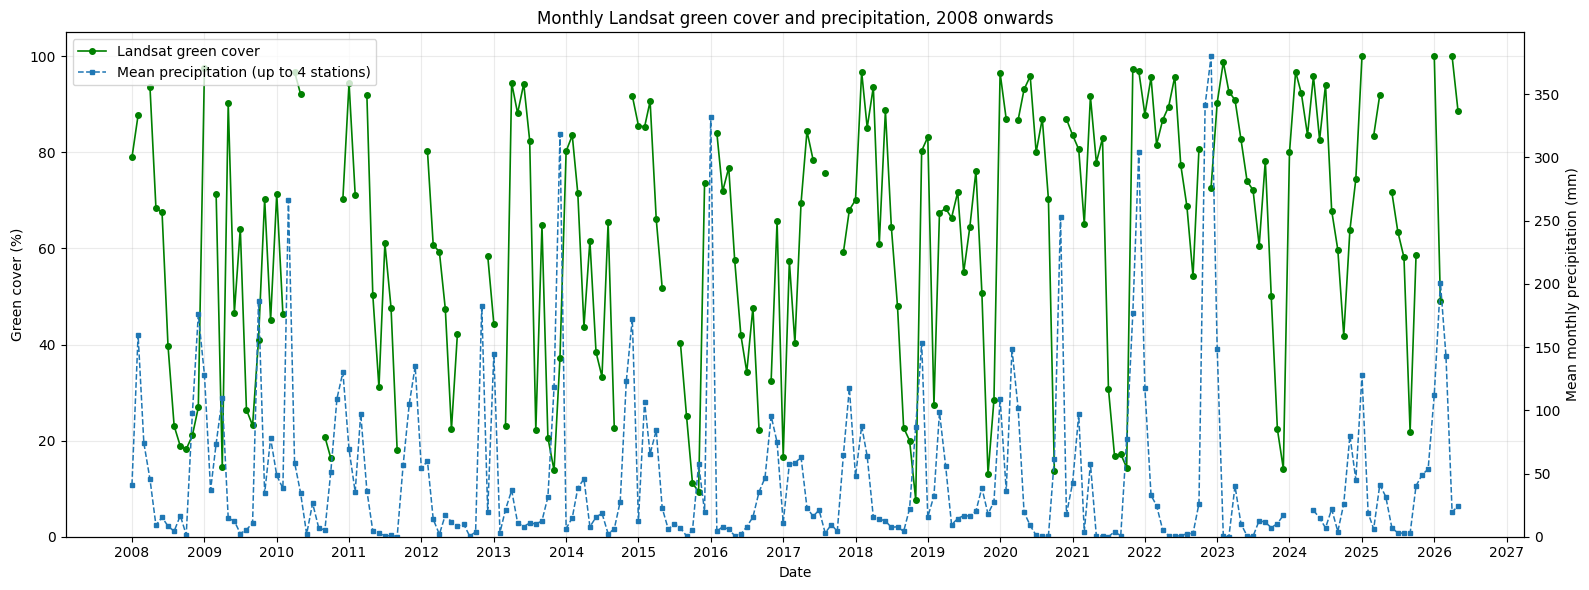

In [33]:
#plot raw landsat green cover and precipitation through time
plot_data = calendar_df.loc[calendar_df["date"] >= plot_start_date].copy()
fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.plot(plot_data["date"],plot_data["green_cover_pct"],
    marker="o", color='g',markersize=4,linewidth=1.2,
    label="Landsat green cover",)
ax1.set_xlabel("Date")
ax1.set_ylabel("Green cover (%)")
ax1.set_ylim(0, 105)
ax2 = ax1.twinx()
ax2.plot(plot_data["date"],plot_data["mean_precip_mm"],
    marker="s",linestyle="--",markersize=3,
    linewidth=1.1,label=f"Mean precipitation (up to {station_count} stations)",)
ax2.set_ylabel("Mean monthly precipitation (mm)")
ax2.set_ylim(bottom=0)
ax1.xaxis.set_major_locator(mdates.YearLocator(1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper left")
ax1.grid(alpha=0.25)
ax1.set_title(f"Monthly Landsat green cover and precipitation, {plot_start_date.year} onwards")
fig.tight_layout()
plt.show()

,month,mean_precip_mm,mean_green_cover_pct,n_months,month_name
0,1,81.583333,74.941553,19,Jan
1,2,64.283333,75.403577,15,Feb
2,3,43.735294,70.659760,17,Mar
3,4,48.517460,79.498982,21,Apr
4,5,14.299123,74.271498,19,May
5,6,17.621930,70.809220,19,Jun
6,7,9.494118,63.561547,17,Jul
7,8,10.301754,49.459245,19,Aug
8,9,9.559167,38.562721,20,Sep
9,10,40.782222,32.684014,15,Oct


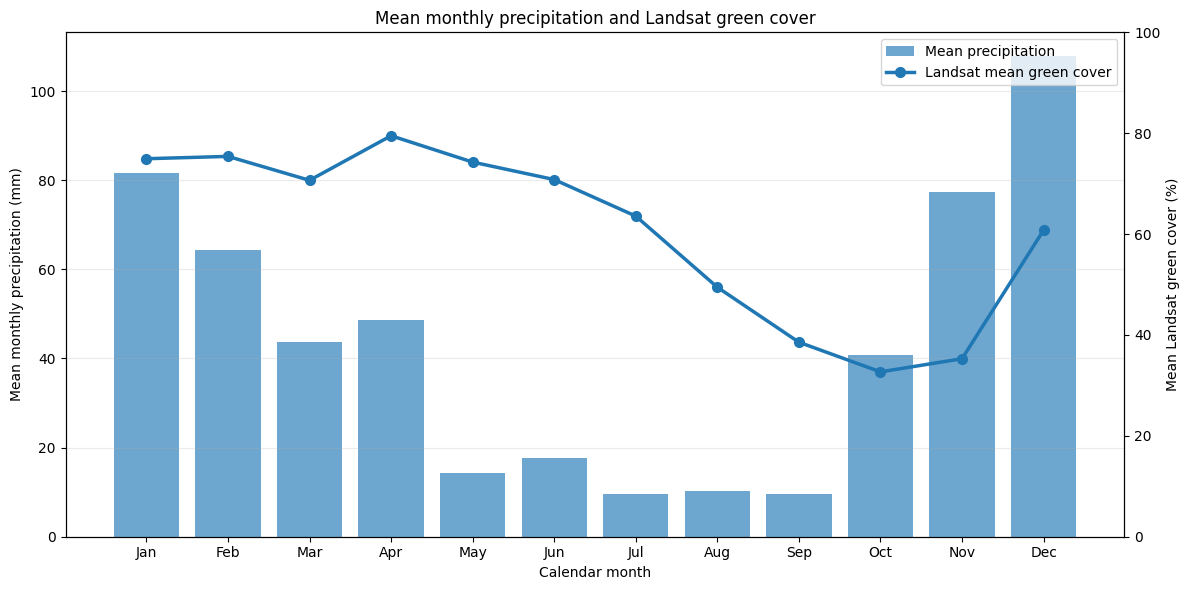

In [34]:
#monthly seasonal averages for matched landsat observations
landsat_monthly = (
    calendar_df.loc[
        calendar_df["has_both"],
        ["date", "green_cover_pct", "mean_precip_mm"],].dropna().copy())
landsat_monthly["month"] = landsat_monthly["date"].dt.month
landsat_climatology = (
    landsat_monthly.groupby("month", as_index=False)
    .agg(mean_precip_mm=("mean_precip_mm", "mean"),
        mean_green_cover_pct=("green_cover_pct", "mean"),
        n_months=("date", "count"),))

landsat_climatology["month_name"] = landsat_climatology["month"].map(
    dict(zip(range(1, 13), month_labels)))

display(landsat_climatology)
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(
    landsat_climatology["month"],
    landsat_climatology["mean_precip_mm"],
    alpha=0.65,
    label="Mean precipitation",)
ax1.set_xlabel("Calendar month")
ax1.set_ylabel("Mean monthly precipitation (mm)")
ax1.set_xticks(range(1, 13), month_labels)
ax1.set_ylim(bottom=0)
ax2 = ax1.twinx()
ax2.plot(landsat_climatology["month"],
    landsat_climatology["mean_green_cover_pct"],
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Landsat mean green cover",)
ax2.set_ylabel("Mean Landsat green cover (%)")
ax2.set_ylim(0, 100)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc="upper right")
ax1.grid(axis="y", alpha=0.25)
ax1.set_title("Mean monthly precipitation and Landsat green cover")
fig.tight_layout()
plt.show()

In [35]:
#full precipitation record and annual summaries
precip_analysis = (precip_df[["date", "mean_precip_mm", "stations_available"]]
    .dropna(subset=["date"])
    .sort_values("date")
    .reset_index(drop=True))
precip_analysis["year"] = precip_analysis["date"].dt.year
precip_analysis["month"] = precip_analysis["date"].dt.month
print(f"Calendar period: {precip_analysis['date'].min():%Y-%m} "
    f"to {precip_analysis['date'].max():%Y-%m}")
print(f"Calendar months: {len(precip_analysis)}")
print("Months with usable precipitation: "
    f"{precip_analysis['mean_precip_mm'].notna().sum()}")

annual_precip = (
    precip_analysis.groupby("year")
    .agg(annual_precip_mm=(
            "mean_precip_mm",
            lambda values: values.sum(min_count=1),),
        avg_monthly_precip_mm=("mean_precip_mm", "mean"),
        median_monthly_precip_mm=("mean_precip_mm", "median"),
        max_monthly_precip_mm=("mean_precip_mm", "max"),
        min_monthly_precip_mm=("mean_precip_mm", "min"),
        precip_months_available=("mean_precip_mm", "count"),
        avg_stations_available=("stations_available", "mean"),
        min_stations_available=("stations_available", "min"),
        max_stations_available=("stations_available", "max"),).reset_index())

annual_precip["complete_precip_year"] = annual_precip["precip_months_available"].eq(complete_year_months)
display(annual_precip)

Calendar period: 2003-01 to 2026-05
Calendar months: 281
Months with usable precipitation: 268


,year,annual_precip_mm,avg_monthly_precip_mm,median_monthly_precip_mm,max_monthly_precip_mm,min_monthly_precip_mm,precip_months_available,avg_stations_available,min_stations_available,max_stations_available,complete_precip_year
0,2003,337.200000,30.654545,15.400000,81.600000,2.400000,11,0.916667,0,1,False
1,2004,747.400000,62.283333,40.600000,295.600000,0.200000,12,1.000000,1,1,True
2,2005,452.000000,64.571429,63.400000,124.800000,9.200000,7,0.583333,0,1,False
3,2006,469.600000,52.177778,25.200000,115.800000,14.400000,9,0.750000,0,1,False
4,2007,725.000000,60.416667,50.100000,254.400000,5.100000,12,1.166667,1,2,True
5,2008,649.200000,54.100000,28.875000,175.866667,1.466667,12,3.083333,2,4,True
6,2009,693.366667,57.780556,35.641667,186.600000,2.533333,12,3.583333,3,4,True
7,2010,778.200000,64.850000,43.375000,266.050000,2.050000,12,4.000000,4,4,True
8,2011,544.066667,45.338889,35.966667,134.900000,0.133333,12,3.333333,2,4,True
9,2012,383.500000,31.958333,12.825000,182.600000,0.500000,12,3.916667,3,4,True


In [36]:
#rank complete precipitation years
complete_years = annual_precip.loc[
    annual_precip["complete_precip_year"]
    & annual_precip["annual_precip_mm"].notna()].copy()

complete_years["wettest_rank"] = (
    complete_years["annual_precip_mm"]
    .rank(method="min", ascending=False)
    .astype("Int64"))
complete_years["driest_rank"] = (
    complete_years["annual_precip_mm"]
    .rank(method="min", ascending=True)
    .astype("Int64"))

top_wettest = complete_years.nsmallest(5, "wettest_rank")[["year", "annual_precip_mm", "avg_monthly_precip_mm", "wettest_rank"]]
top_driest = complete_years.nsmallest(5, "driest_rank")[["year", "annual_precip_mm", "avg_monthly_precip_mm", "driest_rank"]]

print("Top five wettest complete years")
display(top_wettest)
print("Top five driest complete years")
display(top_driest)

Top five wettest complete years


,year,annual_precip_mm,avg_monthly_precip_mm,wettest_rank
19,2022,934.566667,77.880556,1
7,2010,778.200000,64.850000,2
18,2021,764.600000,63.716667,3
17,2020,758.016667,63.168056,4
1,2004,747.400000,62.283333,5


Top five driest complete years


,year,annual_precip_mm,avg_monthly_precip_mm,driest_rank
20,2023,259.000000,21.583333,1
16,2019,363.800000,30.316667,2
9,2012,383.500000,31.958333,3
22,2025,384.000000,32.000000,4
12,2015,398.133333,33.177778,5


In [37]:
#precipitation quartiles and wet/dry definitions
valid_precip = precip_analysis.dropna(subset=["mean_precip_mm"]).copy()
q1 = valid_precip["mean_precip_mm"].quantile(0.25)
q2 = valid_precip["mean_precip_mm"].quantile(0.50)
q3 = valid_precip["mean_precip_mm"].quantile(0.75)
valid_precip["wet_dry_class"] = np.select(
    [valid_precip["mean_precip_mm"] <= q1,valid_precip["mean_precip_mm"] >= q3,],
    ["Dry", "Wet"],default="Intermediate",)
quartile_table = pd.DataFrame(
    {"Quartile": ["Q1 (25%)", "Q2 (50%)", "Q3 (75%)"],
        "Precipitation_mm": [q1, q2, q3],})

print(f"Dry month: precipitation <= {q1:.2f} mm")
print(f"Intermediate month: {q1:.2f} < precipitation < {q3:.2f} mm")
print(f"Wet month: precipitation >= {q3:.2f} mm")
display(quartile_table)
display(valid_precip["wet_dry_class"].value_counts().rename("months").to_frame())

Dry month: precipitation <= 7.89 mm
Intermediate month: 7.89 < precipitation < 63.10 mm
Wet month: precipitation >= 63.10 mm


,Quartile,Precipitation_mm
0,Q1 (25%),7.891667
1,Q2 (50%),23.025000
2,Q3 (75%),63.100000


,months
wet_dry_class,
Intermediate,134
Dry,67
Wet,67


,month,mean_precip_mm,median_precip_mm,min_precip_mm,max_precip_mm,observations,month_name
0,1,88.670455,58.700000,6.450000,332.266667,22,Jan
1,2,64.077778,36.950000,0.200000,254.400000,21,Feb
2,3,65.212319,58.150000,0.000000,266.050000,23,Mar
3,4,47.875758,43.358333,1.900000,109.900000,22,Apr
4,5,18.753788,15.950000,0.400000,70.600000,22,May
5,6,18.794203,12.350000,0.333333,70.400000,23,Jun
6,7,13.093182,8.250000,0.000000,49.200000,22,Jul
7,8,10.640152,6.941667,0.200000,45.400000,22,Aug
8,9,9.148551,6.133333,0.133333,35.466667,23,Sep
9,10,39.312879,29.650000,1.466667,186.600000,22,Oct


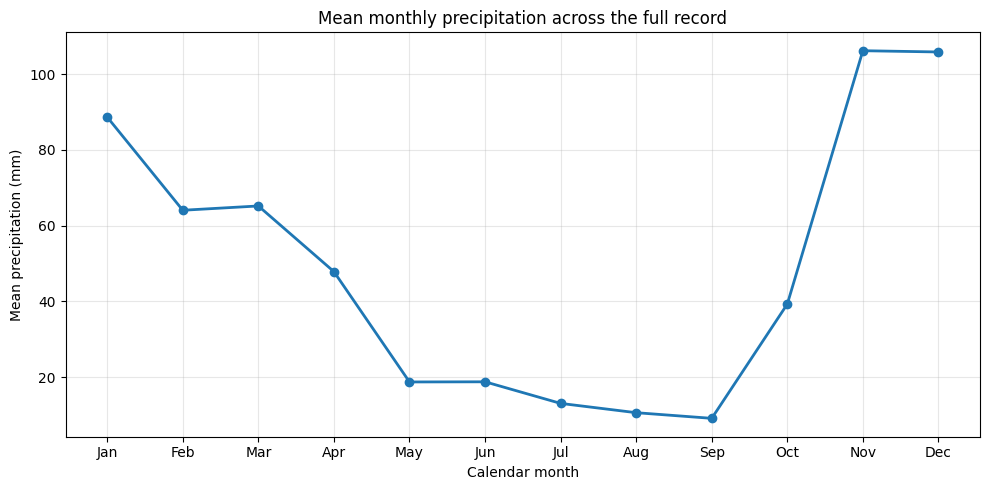

In [38]:
#monthly precipitation climatology
monthly_precip_climatology = (
    valid_precip.groupby("month")
    .agg(mean_precip_mm=("mean_precip_mm", "mean"),
        median_precip_mm=("mean_precip_mm", "median"),
        min_precip_mm=("mean_precip_mm", "min"),
        max_precip_mm=("mean_precip_mm", "max"),
        observations=("mean_precip_mm", "count"),).reset_index())

monthly_precip_climatology["month_name"] = monthly_precip_climatology["month"].map(dict(zip(range(1, 13), month_labels)))
display(monthly_precip_climatology)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_precip_climatology["month"],
    monthly_precip_climatology["mean_precip_mm"],
    marker="o",linewidth=2,)
ax.set_xticks(range(1, 13), month_labels)
ax.set_xlabel("Calendar month")
ax.set_ylabel("Mean precipitation (mm)")
ax.set_title("Mean monthly precipitation across the full record")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

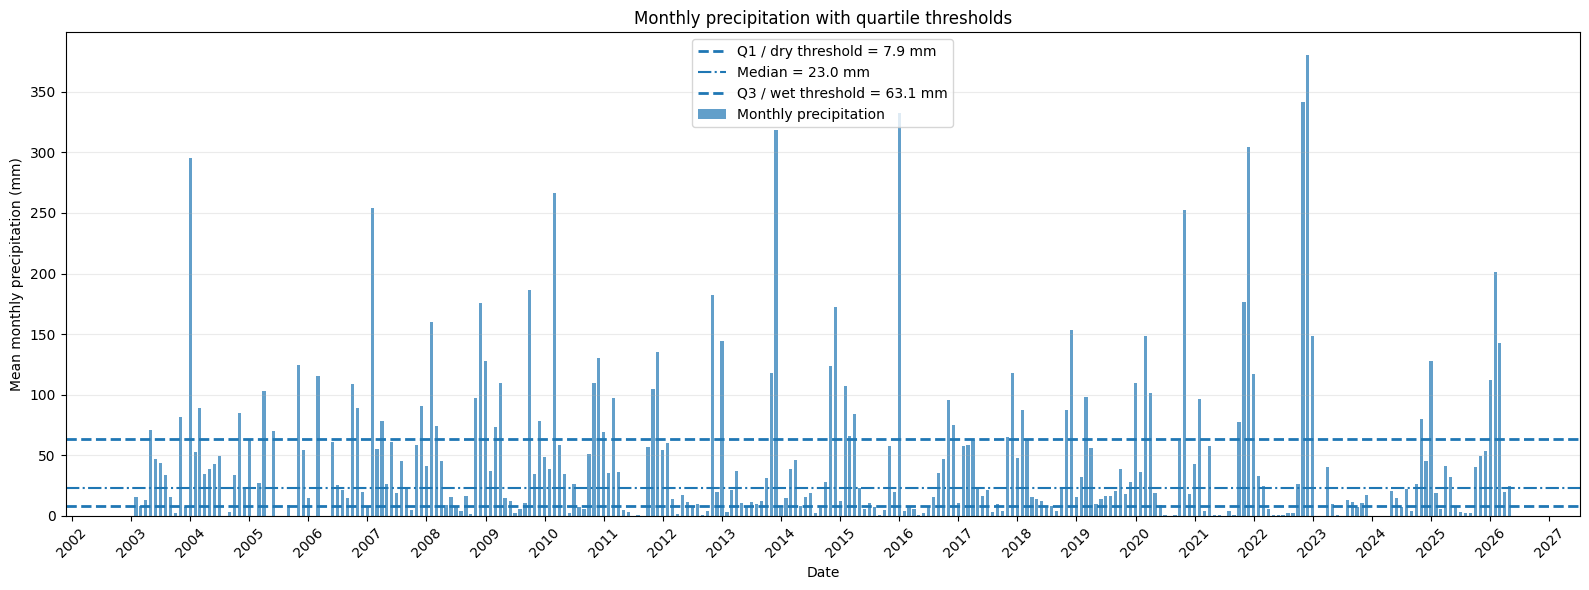

In [39]:
#full precipitation series with quartile thresholds
fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(precip_analysis["date"],
    precip_analysis["mean_precip_mm"],
    width=20,alpha=0.7,
    label="Monthly precipitation",)
ax.axhline(q1, linestyle="--", linewidth=2, label=f"Q1 / dry threshold = {q1:.1f} mm")
ax.axhline(q2, linestyle="-.", linewidth=1.5, label=f"Median = {q2:.1f} mm")
ax.axhline(q3, linestyle="--", linewidth=2, label=f"Q3 / wet threshold = {q3:.1f} mm")
ax.set_xlabel("Date")
ax.set_ylabel("Mean monthly precipitation (mm)")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Monthly precipitation with quartile thresholds")
ax.legend()
ax.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

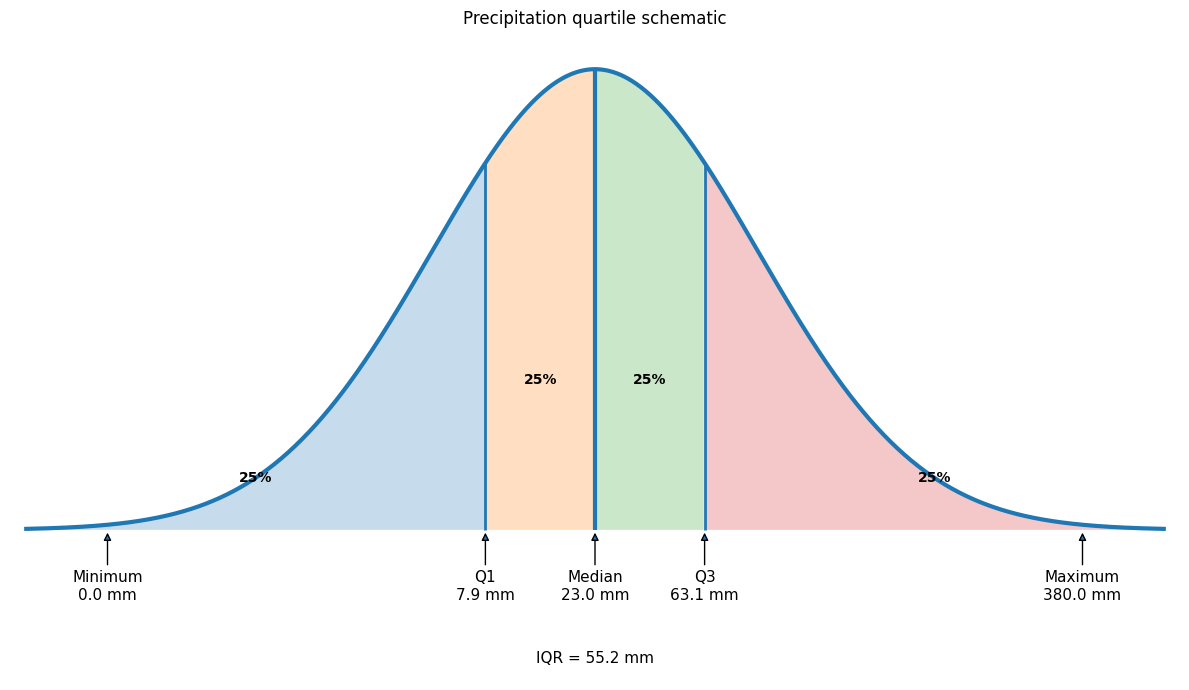

In [40]:
#precipitation quartile schematic - representitive only
precip_values = precip_analysis["mean_precip_mm"].dropna().to_numpy()
minimum = np.min(precip_values)
q1_plot = np.quantile(precip_values, 0.25)
median_plot = np.quantile(precip_values, 0.50)
q3_plot = np.quantile(precip_values, 0.75)
maximum = np.max(precip_values)
iqr = q3_plot - q1_plot
x = np.linspace(-3.5, 3.5, 1000)
y = norm.pdf(x)
q1_x = norm.ppf(0.25)
median_x = norm.ppf(0.50)
q3_x = norm.ppf(0.75)
fig, ax = plt.subplots(figsize=(12, 7))
ax.plot(x, y, linewidth=3)
regions = [(-3.5, q1_x),(q1_x, median_x),
    (median_x, q3_x),(q3_x, 3.5),]
for left, right in regions:
    mask = (x >= left) & (x <= right)
    ax.fill_between(x[mask], 0, y[mask], alpha=0.25)
for xpos, width in [(q1_x, 2), (median_x, 3), (q3_x, 2)]:
    ax.vlines(xpos, 0, norm.pdf(xpos), linewidth=width)
for xpos, ypos in zip(
    [(-3.5 + q1_x) / 2,(q1_x + median_x) / 2,(median_x + q3_x) / 2,(q3_x + 3.5) / 2,],
    [0.045, 0.13, 0.13, 0.045],):
    ax.text(xpos, ypos, "25%", ha="center", va="center", fontweight="bold")

labels = [(-3.0, f"Minimum\n{minimum:.1f} mm"),
    (q1_x, f"Q1\n{q1_plot:.1f} mm"),
    (median_x, f"Median\n{median_plot:.1f} mm"),
    (q3_x, f"Q3\n{q3_plot:.1f} mm"),
    (3.0, f"Maximum\n{maximum:.1f} mm"),]
for xpos, label in labels:
    ax.annotate(label,xy=(xpos, 0),xytext=(xpos, -0.035),ha="center",
        va="top",fontsize=11,arrowprops=dict(arrowstyle="-|>"),)
ax.text(0,-0.105,f"IQR = {iqr:.1f} mm",ha="center",va="top",fontsize=11,)
ax.set_title("Precipitation quartile schematic")
ax.set_xlim(-3.6, 3.6)
ax.set_ylim(-0.13, y.max() * 1.08)
ax.axis("off")
fig.tight_layout()
plt.show()

In [41]:
#green cover during dry and wet months
relationship_all = (
    calendar_df.loc[calendar_df["has_both"],
        ["date", "green_cover_pct", "mean_precip_mm"],].dropna().copy())
relationship_all["rainfall_group"] = np.select(
    [relationship_all["mean_precip_mm"] <= q1,relationship_all["mean_precip_mm"] >= q3,],
    ["Dry months", "Wet months"],default="Intermediate months",)
green_wet_dry_summary = (
    relationship_all.loc[relationship_all["rainfall_group"].isin(["Dry months", "Wet months"])]
    .groupby("rainfall_group")
    .agg(observations=("green_cover_pct", "count"),
        avg_precip_mm=("mean_precip_mm", "mean"),
        avg_green_cover_pct=("green_cover_pct", "mean"),
        median_green_cover_pct=("green_cover_pct", "median"),
        min_green_cover_pct=("green_cover_pct", "min"),
        max_green_cover_pct=("green_cover_pct", "max"),).reset_index())
display(green_wet_dry_summary)

,rainfall_group,observations,avg_precip_mm,avg_green_cover_pct,median_green_cover_pct,min_green_cover_pct,max_green_cover_pct
0,Dry months,59,3.304520,56.649061,62.150350,11.111111,98.810144
1,Wet months,48,126.584722,64.726114,70.827975,3.753351,100.000000


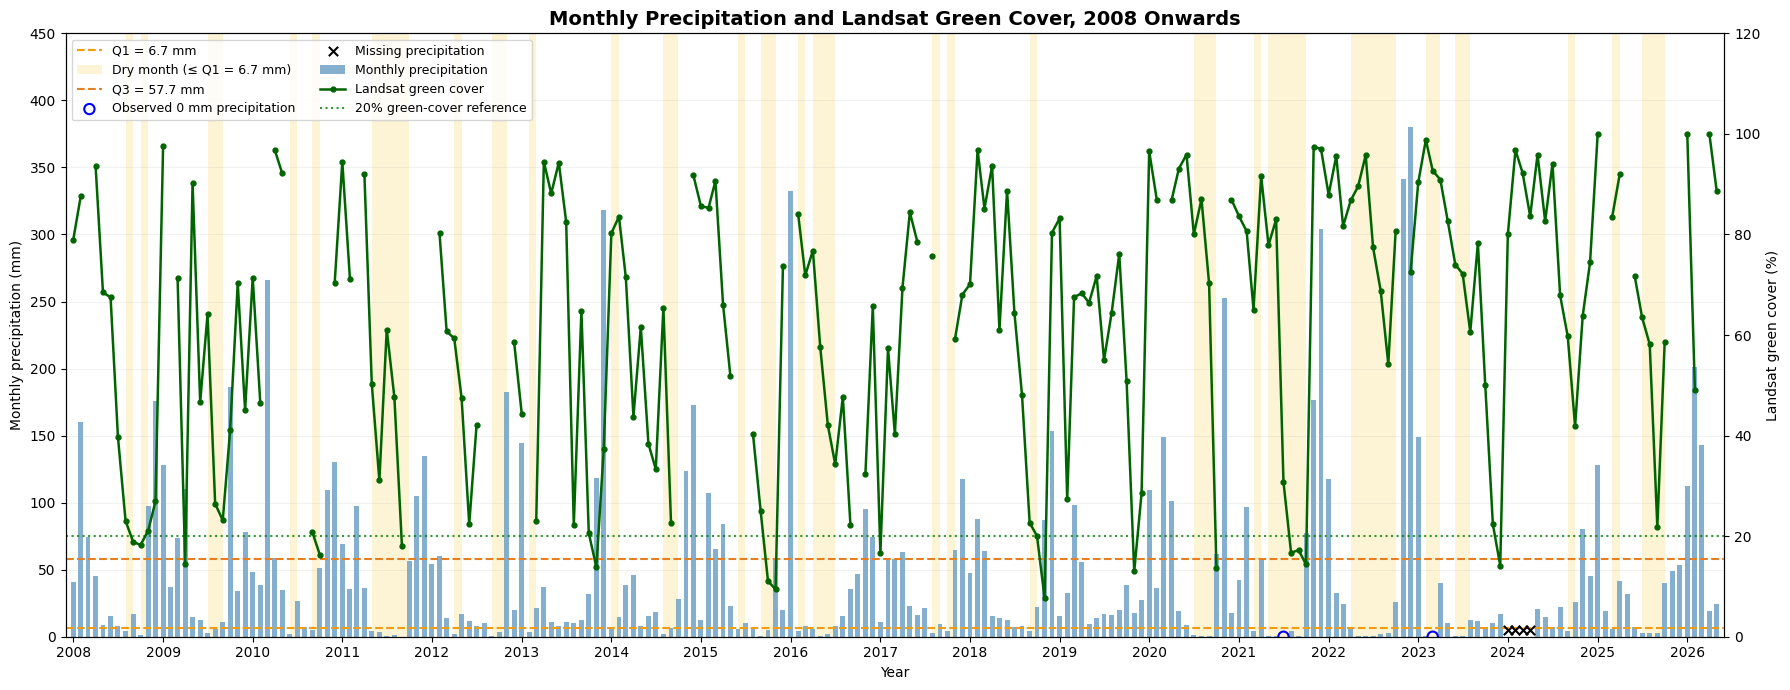

In [42]:
#full landsat and precipitation timeline from 2008
landsat_timeline = (
    calendar_df.loc[
        calendar_df["date"] >= plot_start_date,
        ["date", "mean_precip_mm", "green_cover_pct"],]
    .sort_values("date")
    .copy())
matched_from_2008 = landsat_timeline.dropna(
    subset=["mean_precip_mm", "green_cover_pct"])
q1_landsat = matched_from_2008["mean_precip_mm"].quantile(0.25)
q3_landsat = matched_from_2008["mean_precip_mm"].quantile(0.75)

#identify dry, zero and missing precipitation months
dry_mask = (landsat_timeline["mean_precip_mm"].notna()
            & landsat_timeline["mean_precip_mm"].le(q1_landsat))
zero_precip_mask = landsat_timeline["mean_precip_mm"].eq(0)
missing_precip_mask = landsat_timeline["mean_precip_mm"].isna()

fig, ax_precip = plt.subplots(figsize=(18, 7))

#shade dry months
for date in landsat_timeline.loc[dry_mask, "date"]:
    ax_precip.axvspan(
        date, date + pd.DateOffset(months=1),
        color="#F7D96B", alpha=0.28, linewidth=0, zorder=0)

#precipitation
ax_precip.bar(
    landsat_timeline["date"], landsat_timeline["mean_precip_mm"],
    width=20, color="#77A6C9", alpha=0.90,
    label="Monthly precipitation", zorder=2)
ax_precip.axhline(
    q1_landsat, color="#F39C12", linestyle="--", linewidth=1.5,
    label=f"Q1 = {q1_landsat:.1f} mm", zorder=3)
ax_precip.axhline(
    q3_landsat, color="#E67E22", linestyle="--", linewidth=1.5,
    label=f"Q3 = {q3_landsat:.1f} mm", zorder=3)

#zero and missing precipitation
ax_precip.scatter(
    landsat_timeline.loc[zero_precip_mask, "date"],
    np.zeros(zero_precip_mask.sum()),
    facecolors="none", edgecolors="blue", s=55, linewidth=1.5,
    label="Observed 0 mm precipitation", zorder=6)
ax_precip.scatter(
    landsat_timeline.loc[missing_precip_mask, "date"],
    np.full(missing_precip_mask.sum(), 5),
    marker="x", color="black", s=45, linewidth=1.5,
    label="Missing precipitation", zorder=6)

ax_precip.set_xlabel("Year")
ax_precip.set_ylabel("Monthly precipitation (mm)")
ax_precip.set_ylim(0, 450)
ax_precip.xaxis.set_major_locator(mdates.YearLocator(1))
ax_precip.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_precip.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.20)

#landsat green cover
ax_green = ax_precip.twinx()
ax_green.plot(
    landsat_timeline["date"], landsat_timeline["green_cover_pct"],
    color="darkgreen", linewidth=1.8, marker="o", markersize=3.5,
    label="Landsat green cover", zorder=5)
ax_green.axhline(
    20, color="green", linestyle=":", linewidth=1.5, alpha=0.8,
    label="20% green-cover reference")
ax_green.set_ylabel("Landsat green cover (%)")
ax_green.set_ylim(0, 120)

#legend
dry_patch = Patch(
    facecolor="#F7D96B", alpha=0.28,
    label=f"Dry month (≤ Q1 = {q1_landsat:.1f} mm)")
handles_precip, labels_precip = ax_precip.get_legend_handles_labels()
handles_green, labels_green = ax_green.get_legend_handles_labels()
combined_handles = [handles_precip[0], dry_patch] + handles_precip[1:] + handles_green
combined_labels = [
    labels_precip[0], f"Dry month (≤ Q1 = {q1_landsat:.1f} mm)"] + labels_precip[1:] + labels_green
ax_precip.legend(
    combined_handles, combined_labels,
    loc="upper left", ncol=2, fontsize=9, frameon=True)
ax_precip.set_title(
    "Monthly Precipitation and Landsat Green Cover, 2008 Onwards",
    fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
ax_precip.set_xlim(
    landsat_timeline["date"].min() - pd.DateOffset(months=1),
    landsat_timeline["date"].max() + pd.DateOffset(months=1))
fig.tight_layout()
plt.show()

In [43]:
#same-month correlation between precipitation and landsat green cover
corr_data = landsat_timeline.dropna(subset=["mean_precip_mm", "green_cover_pct"]).copy()
spearman_rho, spearman_p = spearmanr(corr_data["mean_precip_mm"],corr_data["green_cover_pct"],)
pearson_r, pearson_p = pearsonr(corr_data["mean_precip_mm"],corr_data["green_cover_pct"],)
correlation_summary = pd.DataFrame({"method": ["Spearman", "Pearson"],"coefficient": [spearman_rho, pearson_r],
                                    "p_value": [spearman_p, pearson_p],"observations": [len(corr_data), len(corr_data)],})
display(correlation_summary.round(4))

,method,coefficient,p_value,observations
0,Spearman,0.1401,0.0585,183
1,Pearson,0.0992,0.1815,183


Landsat matched seasonal averages


,month,mean_green_cover_pct,mean_precip_mm,observations,month_name
0,1,74.94,81.58,19,Jan
1,2,75.40,64.28,15,Feb
2,3,70.66,43.74,17,Mar
3,4,79.50,48.52,21,Apr
4,5,74.27,14.30,19,May
5,6,70.81,17.62,19,Jun
6,7,63.56,9.49,17,Jul
7,8,49.46,10.30,19,Aug
8,9,38.56,9.56,20,Sep
9,10,32.68,40.78,15,Oct



Precipitation quartiles for Landsat-matched months
Minimum: 0.00 mm
Q1: 7.50 mm
Median: 19.43 mm
Q3: 58.56 mm
Maximum: 380.00 mm
IQR: 51.06 mm


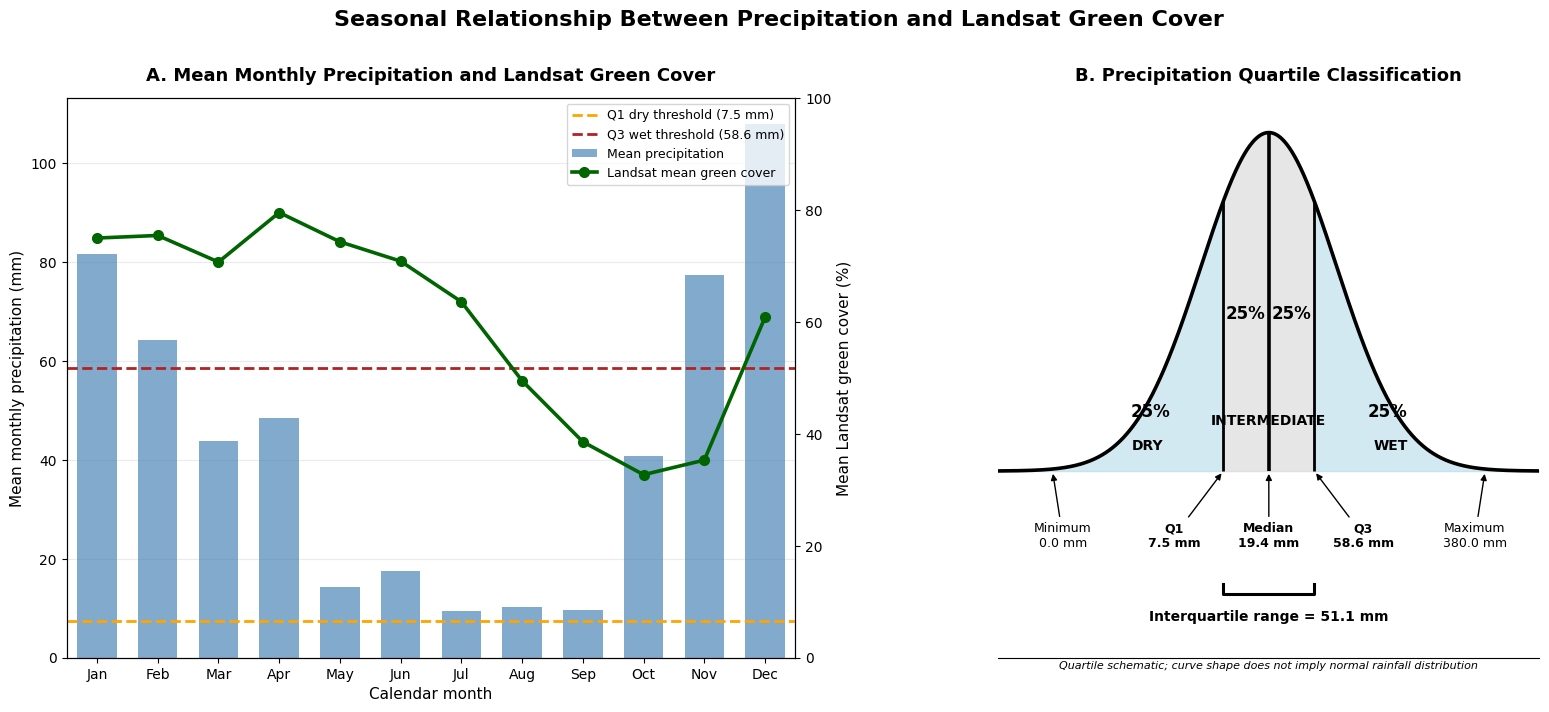

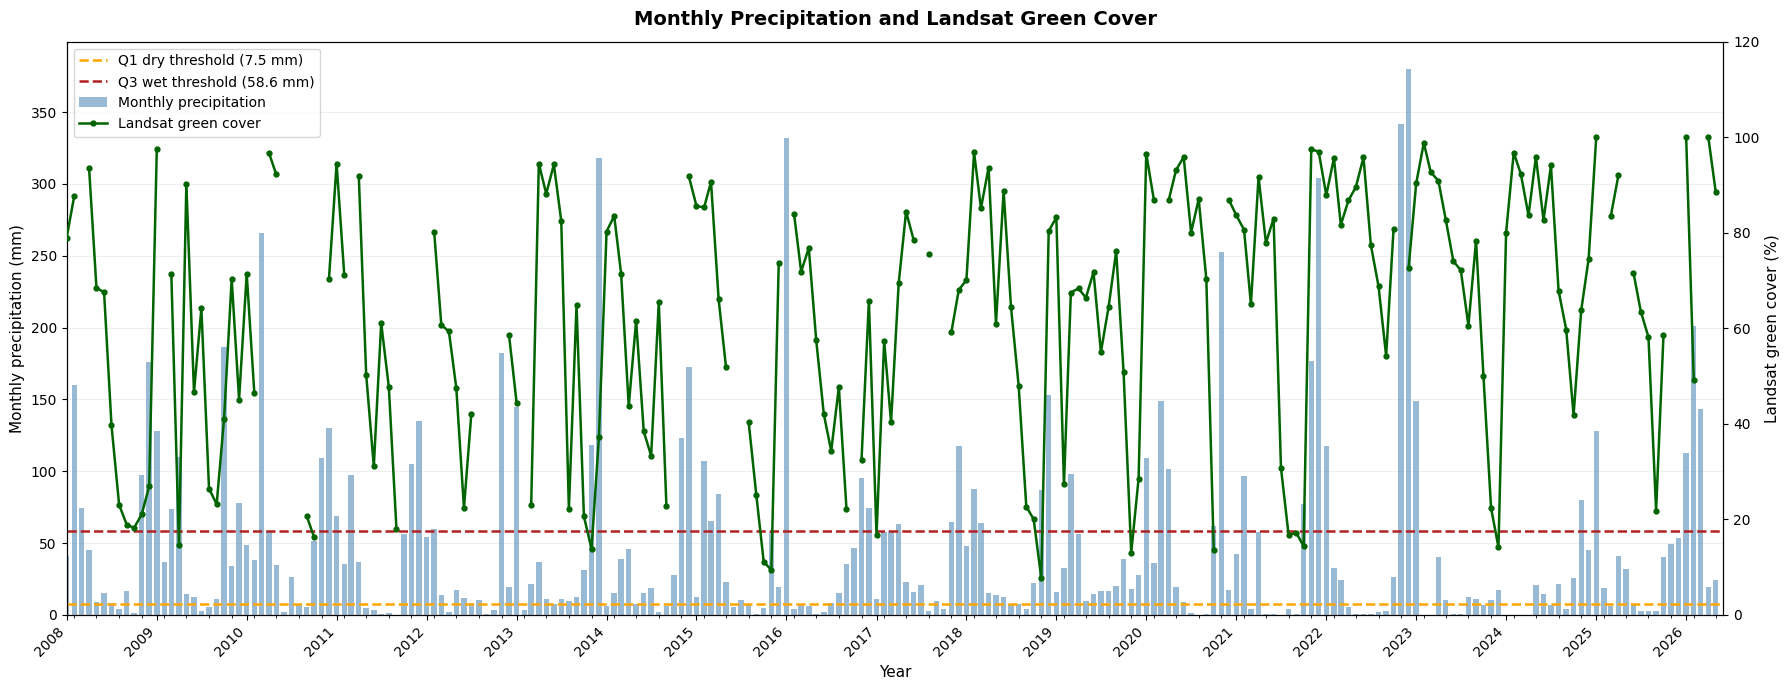

In [44]:
#landsat seasonal analysis
landsat_matched = (
    calendar_df.loc[calendar_df["has_both"],
        ["date", "green_cover_pct", "mean_precip_mm"]]
    .dropna(subset=["green_cover_pct", "mean_precip_mm"])
    .sort_values("date").copy())
landsat_matched["month"] = landsat_matched["date"].dt.month

#monthly seasonal averages
landsat_seasonal = (
    landsat_matched.groupby("month", as_index=False)
    .agg(mean_green_cover_pct=("green_cover_pct", "mean"),
        mean_precip_mm=("mean_precip_mm", "mean"),
        observations=("date", "count")))

landsat_seasonal["month_name"] = landsat_seasonal["month"].map(
    dict(zip(range(1, 13), month_labels)))

print("Landsat matched seasonal averages")
display(landsat_seasonal.round(2))

#precipitation quartiles
precip_values = landsat_matched["mean_precip_mm"].dropna().to_numpy()

minimum = np.min(precip_values)
q1 = np.quantile(precip_values, 0.25)
median = np.quantile(precip_values, 0.50)
q3 = np.quantile(precip_values, 0.75)
maximum = np.max(precip_values)
iqr = q3 - q1

print("\nPrecipitation quartiles for Landsat-matched months")
print(f"Minimum: {minimum:.2f} mm")
print(f"Q1: {q1:.2f} mm")
print(f"Median: {median:.2f} mm")
print(f"Q3: {q3:.2f} mm")
print(f"Maximum: {maximum:.2f} mm")
print(f"IQR: {iqr:.2f} mm")

#seasonal and quartile figure
fig = plt.figure(figsize=(19, 8))
gs = fig.add_gridspec(
    1, 2,
    width_ratios=[1.55, 1.15],
    wspace=0.32)

#seasonal precipitation and green cover
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(landsat_seasonal["month"],
    landsat_seasonal["mean_precip_mm"],
    width=0.65,color="steelblue",
    alpha=0.68,label="Mean precipitation",zorder=2)
ax1.axhline(q1,
    color="orange",linestyle="--",
    linewidth=2,label=f"Q1 dry threshold ({q1:.1f} mm)",zorder=4)
ax1.axhline(q3,color="firebrick",
    linestyle="--",linewidth=2,
    label=f"Q3 wet threshold ({q3:.1f} mm)",zorder=4)
ax1.set_xlabel("Calendar month", fontsize=11)
ax1.set_ylabel("Mean monthly precipitation (mm)", fontsize=11)
ax1.set_xticks(range(1, 13), month_labels)
ax1.set_xlim(0.5, 12.5)
ax1.set_ylim(bottom=0)
ax1.grid(axis="y", alpha=0.25, zorder=1)

# landsat green cover
ax1_green = ax1.twinx()
ax1_green.plot(landsat_seasonal["month"],landsat_seasonal["mean_green_cover_pct"],color="darkgreen",
    marker="o",linewidth=2.6,markersize=7,label="Landsat mean green cover",zorder=5)
ax1_green.set_ylabel("Mean Landsat green cover (%)", fontsize=11)
ax1_green.set_ylim(0, 100)
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax1_green.get_legend_handles_labels()
ax1.legend(handles1 + handles2,labels1 + labels2,loc="upper right",frameon=True,fontsize=9)

ax1.set_title("A. Mean Monthly Precipitation and Landsat Green Cover",
    fontsize=13,fontweight="bold",pad=12)

#precipitation quartile schematic
axq = fig.add_subplot(gs[0, 1])
x = np.linspace(-4.0, 4.0, 1500)
y = norm.pdf(x)
q1_x = norm.ppf(0.25)
median_x = 0
q3_x = norm.ppf(0.75)
axq.plot(x, y,color="black",linewidth=2.6)

#shade quartiles
quartile_regions = [(-4.0, q1_x, "lightblue"),
    (q1_x, median_x, "lightgrey"),(median_x, q3_x, "lightgrey"),(q3_x, 4.0, "lightblue")]

for left, right, colour in quartile_regions:
    mask = (x >= left) & (x <= right)
    axq.fill_between(x[mask], 0, y[mask],color=colour,alpha=0.55)

#quartile lines
for xpos, width in [
    (q1_x, 2),(median_x, 2.6),
    (q3_x, 2)]:
    axq.vlines(xpos, 0, norm.pdf(xpos),
        color="black",linewidth=width)

#quartile percentages
quartile_label_positions = [
    (-1.75, 0.070),
    (-0.34, 0.185),
    (0.34, 0.185),
    (1.75, 0.070)]

for xpos, ypos in quartile_label_positions:
    axq.text(xpos, ypos, "25%",ha="center",va="center",fontsize=12,fontweight="bold")

#rainfall classes
axq.text(-1.80, 0.025, "DRY",ha="center",fontsize=10,fontweight="bold")
axq.text(0, 0.055, "INTERMEDIATE",ha="center",fontsize=10,fontweight="bold")
axq.text(1.80, 0.025, "WET",ha="center",fontsize=10,fontweight="bold")

#quartile values
value_y = -0.060
axq.annotate(f"Minimum\n{minimum:.1f} mm",
    xy=(-3.2, 0),xytext=(-3.05, value_y),
    ha="center",va="top",fontsize=9,arrowprops=dict(arrowstyle="-|>",linewidth=1,color="black"))
axq.annotate(f"Q1\n{q1:.1f} mm",xy=(q1_x, 0),xytext=(-1.40, value_y),ha="center",
    va="top",fontsize=9,fontweight="bold",arrowprops=dict(arrowstyle="-|>",linewidth=1,color="black"))
axq.annotate(f"Median\n{median:.1f} mm",xy=(0, 0),xytext=(0, value_y),ha="center",
    va="top",fontsize=9,fontweight="bold",arrowprops=dict(arrowstyle="-|>",linewidth=1,color="black"))
axq.annotate(f"Q3\n{q3:.1f} mm",xy=(q3_x, 0),xytext=(1.40, value_y),ha="center",
    va="top",fontsize=9,fontweight="bold",arrowprops=dict(arrowstyle="-|>",linewidth=1,color="black"))
axq.annotate(f"Maximum\n{maximum:.1f} mm",xy=(3.2, 0),xytext=(3.05, value_y),ha="center",
    va="top",fontsize=9,arrowprops=dict(arrowstyle="-|>",linewidth=1,color="black"))

#iqr bracket
bracket_y = -0.145
axq.plot([q1_x, q1_x, q3_x, q3_x],[bracket_y + 0.012, bracket_y,
     bracket_y, bracket_y + 0.012],color="black",linewidth=2.2)
axq.text(0,bracket_y - 0.018, f"Interquartile range = {iqr:.1f} mm",ha="center",
    va="top",fontsize=10,fontweight="bold")
axq.set_title("B. Precipitation Quartile Classification",fontsize=13,fontweight="bold",pad=12)
axq.set_xlim(-4.0, 4.0)
axq.set_ylim(-0.22, 0.44)
axq.set_xticks([])
axq.set_yticks([])
axq.spines["left"].set_visible(False)
axq.spines["right"].set_visible(False)
axq.spines["top"].set_visible(False)
axq.text(0.5, -0.02,
    "Quartile schematic; curve shape does not imply normal rainfall distribution",
    transform=axq.transAxes,ha="center",fontsize=8,style="italic")
fig.suptitle("Seasonal Relationship Between Precipitation and Landsat Green Cover",
    fontsize=16, fontweight="bold", y=0.99)
fig.subplots_adjust(top=0.88,bottom=0.18)
plt.show()

#full monthly landsat and precipitation time series
timeline_start = pd.Timestamp("2008-01-01")

landsat_timeline = (calendar_df.loc[calendar_df["date"] >= timeline_start,
        ["date", "green_cover_pct", "mean_precip_mm"]].sort_values("date").copy())
fig, ax_precip = plt.subplots(figsize=(18, 7))

#precipitation
ax_precip.bar(landsat_timeline["date"],landsat_timeline["mean_precip_mm"],
    width=22,color="steelblue",alpha=0.55,label="Monthly precipitation",zorder=2)
ax_precip.axhline(q1,color="orange",linestyle="--",linewidth=1.8,
    label=f"Q1 dry threshold ({q1:.1f} mm)",zorder=3)
ax_precip.axhline(q3,color="firebrick",linestyle="--",linewidth=1.8,
    label=f"Q3 wet threshold ({q3:.1f} mm)",zorder=3)
ax_precip.set_xlabel("Year", fontsize=11)
ax_precip.set_ylabel("Monthly precipitation (mm)", fontsize=11)
ax_precip.set_ylim(bottom=0)
ax_precip.grid(axis="y", alpha=0.20, zorder=1)

# landsat green cover
ax_green = ax_precip.twinx()
ax_green.plot(landsat_timeline["date"],landsat_timeline["green_cover_pct"],
    color="darkgreen",linewidth=1.8,marker="o",markersize=3.5,
    label="Landsat green cover",zorder=5)
ax_green.set_ylabel("Landsat green cover (%)", fontsize=11)
ax_green.set_ylim(0, 120)

#date formatting
ax_precip.xaxis.set_major_locator(mdates.YearLocator(1))
ax_precip.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax_precip.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax_precip.set_xlim(timeline_start,
    landsat_timeline["date"].max() + pd.DateOffset(months=1))
plt.setp(ax_precip.get_xticklabels(),rotation=45,ha="right")

#legend
handles1, labels1 = ax_precip.get_legend_handles_labels()
handles2, labels2 = ax_green.get_legend_handles_labels()
ax_precip.legend(handles1 + handles2,labels1 + labels2,
    loc="upper left",frameon=True,fontsize=10)
ax_precip.set_title("Monthly Precipitation and Landsat Green Cover",
    fontsize=14,fontweight="bold",pad=12)
fig.tight_layout()
plt.show()

,lag_months,observations,spearman_rho,spearman_p,pearson_r,pearson_p,spearman_significant_0.05,pearson_significant_0.05
0,0,183,0.1401,0.0585,0.0992,0.1815,False,False
1,1,182,0.4137,0.0000,0.3640,0.0000,True,True
2,2,181,0.4264,0.0000,0.3541,0.0000,True,True
3,3,181,0.3453,0.0000,0.3253,0.0000,True,True
4,4,180,0.1166,0.1190,0.1540,0.0390,False,True
5,5,179,-0.0039,0.9587,0.1030,0.1701,False,False
6,6,178,-0.1607,0.0321,-0.0631,0.4030,True,False


Strongest positive Spearman relationship: 2-month lag, rho = 0.426, p = 2.17e-09
Strongest positive Pearson relationship: 1-month lag, r = 0.364, p = 4.376e-07


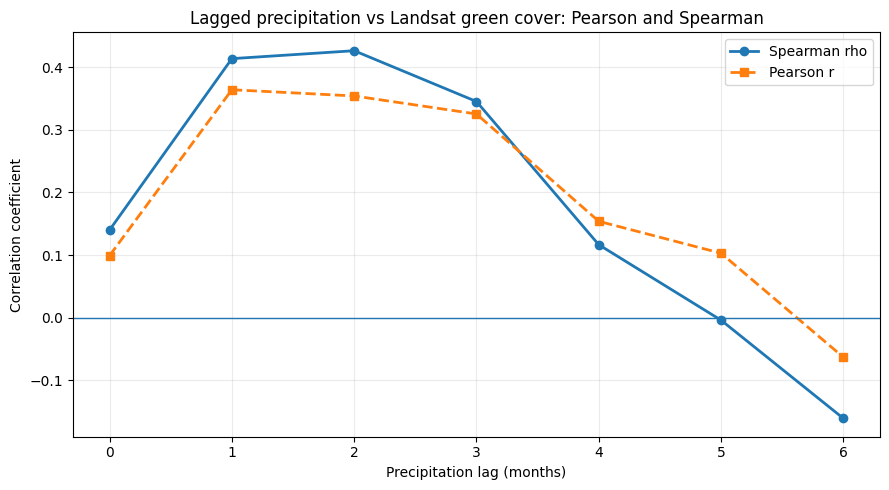

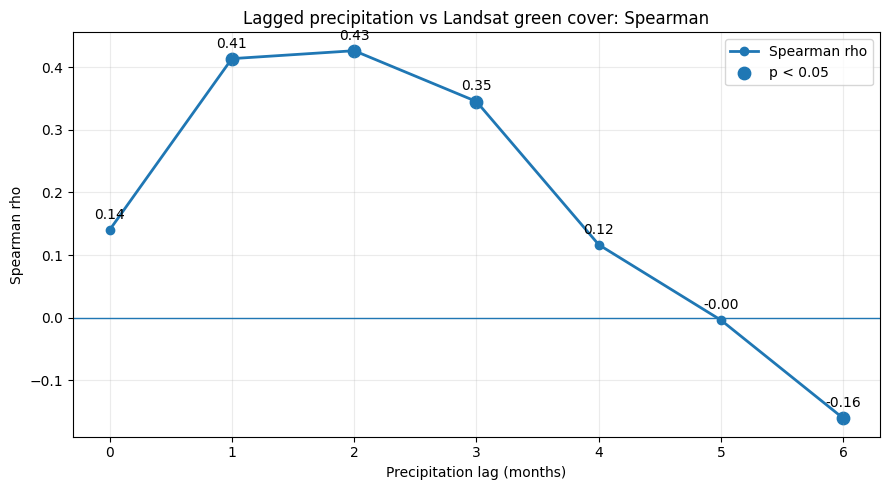

In [45]:
#lagged precipitation-to-green-cover correlation
lag_data = (landsat_timeline[["date", "mean_precip_mm", "green_cover_pct"]]
    .sort_values("date").copy())

full_index = pd.date_range(lag_data["date"].min(),
    lag_data["date"].max(),freq="MS",)
lag_data = (lag_data.set_index("date").reindex(full_index).rename_axis("date").reset_index())
max_lag = 6
lag_results = []
for lag in range(max_lag + 1):
    temp = lag_data.copy()
    temp["lagged_precip_mm"] = temp["mean_precip_mm"].shift(lag)
    paired = temp[["green_cover_pct", "lagged_precip_mm"]].dropna()

    if len(paired) >= 3:
        spearman_rho, spearman_p = spearmanr(
            paired["lagged_precip_mm"],
            paired["green_cover_pct"],)
        pearson_r, pearson_p = pearsonr(
            paired["lagged_precip_mm"],
            paired["green_cover_pct"],)
    else:
        spearman_rho = spearman_p = np.nan
        pearson_r = pearson_p = np.nan

    lag_results.append({"lag_months": lag,"observations": len(paired),
            "spearman_rho": spearman_rho,"spearman_p": spearman_p,
            "pearson_r": pearson_r,"pearson_p": pearson_p,})
lag_results_df = pd.DataFrame(lag_results)
lag_results_df["spearman_significant_0.05"] = lag_results_df["spearman_p"] < 0.05
lag_results_df["pearson_significant_0.05"] = lag_results_df["pearson_p"] < 0.05
display(lag_results_df.round(4))
best_spearman_row = lag_results_df.loc[lag_results_df["spearman_rho"].idxmax()]
best_pearson_row = lag_results_df.loc[lag_results_df["pearson_r"].idxmax()]
best_lag = int(best_spearman_row["lag_months"])

print(f"Strongest positive Spearman relationship: "
    f"{int(best_spearman_row['lag_months'])}-month lag, "
    f"rho = {best_spearman_row['spearman_rho']:.3f}, "
    f"p = {best_spearman_row['spearman_p']:.4g}")
print(f"Strongest positive Pearson relationship: "
    f"{int(best_pearson_row['lag_months'])}-month lag, "
    f"r = {best_pearson_row['pearson_r']:.3f}, "
    f"p = {best_pearson_row['pearson_p']:.4g}")

#combined pearson and spearman graph
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lag_results_df["lag_months"],lag_results_df["spearman_rho"],
    marker="o",linewidth=2,label="Spearman rho",)
ax.plot(lag_results_df["lag_months"],lag_results_df["pearson_r"],
    marker="s",linewidth=2,linestyle="--",label="Pearson r",)
ax.axhline(0, linewidth=1)
ax.set_xlabel("Precipitation lag (months)")
ax.set_ylabel("Correlation coefficient")
ax.set_title("Lagged precipitation vs Landsat green cover: Pearson and Spearman")
ax.set_xticks(range(max_lag + 1))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

#separate spearman graph
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(lag_results_df["lag_months"],lag_results_df["spearman_rho"],
    marker="o",linewidth=2,label="Spearman rho",)
significant = lag_results_df["spearman_significant_0.05"]
ax.scatter(lag_results_df.loc[significant, "lag_months"],
    lag_results_df.loc[significant, "spearman_rho"],s=80,label="p < 0.05",)
for _, row in lag_results_df.iterrows():
    ax.annotate(f"{row['spearman_rho']:.2f}",
        (row["lag_months"], row["spearman_rho"]),
        xytext=(0, 8),textcoords="offset points",ha="center",)
ax.axhline(0, linewidth=1)
ax.set_xlabel("Precipitation lag (months)")
ax.set_ylabel("Spearman rho")
ax.set_title("Lagged precipitation vs Landsat green cover: Spearman")
ax.set_xticks(range(max_lag + 1))
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

In [46]:
#full record spearman index using the strongest lag
spearman_lag_data = (landsat_timeline[["date", "mean_precip_mm", "green_cover_pct"]]
    .sort_values("date").copy())
full_monthly_index = pd.date_range(spearman_lag_data["date"].min(),spearman_lag_data["date"].max(),
    freq="MS")
spearman_lag_data = (spearman_lag_data.set_index("date").reindex(full_monthly_index)
    .rename_axis("date").reset_index())
spearman_lag_data["lagged_precip_mm"] = (spearman_lag_data["mean_precip_mm"].shift(best_lag))
lagged_pairs = spearman_lag_data.dropna(subset=["green_cover_pct", "lagged_precip_mm"])
rho, p_value = spearmanr(lagged_pairs["lagged_precip_mm"],lagged_pairs["green_cover_pct"],)
print(f"Lag used: {best_lag} months")
print(f"Observations: {len(lagged_pairs)}")
print(f"Spearman rho: {rho:.3f}")
print(f"p-value: {p_value:.4g}")

Lag used: 2 months
Observations: 181
Spearman rho: 0.426
p-value: 2.17e-09


In [47]:
#drought events, resistance, recovery and resilience
drought_data = (landsat_timeline[["date", "mean_precip_mm", "green_cover_pct"]]
    .sort_values("date").copy())
full_monthly_index = pd.date_range(drought_data["date"].min(),drought_data["date"].max(),freq="MS",)
drought_data = (drought_data.set_index("date").reindex(full_monthly_index).rename_axis("date")
    .reset_index())
drought_q1 = drought_data["mean_precip_mm"].dropna().quantile(0.25)
drought_data["dry_month"] = drought_data["mean_precip_mm"].le(drought_q1)

#consecutive dry-month runs
new_run = drought_data["dry_month"].ne(drought_data["dry_month"].shift(fill_value=False))
drought_data["run_id"] = new_run.cumsum()
dry_runs = (drought_data.loc[drought_data["dry_month"]].groupby("run_id")
    .agg(drought_start=("date", "min"),drought_end=("date", "max"),drought_duration_months=("date", "size"),)
    .reset_index(drop=True))
dry_runs = dry_runs.loc[dry_runs["drought_duration_months"] >= 2].reset_index(drop=True)
event_rows = []
recovery_fraction = 0.90
pre_drought_months = 3
impact_lag_months = best_lag
for event_number, event in dry_runs.iterrows():
    start = event["drought_start"]
    end = event["drought_end"]
    pre_start = start - pd.DateOffset(months=pre_drought_months)
    pre_end = start - pd.DateOffset(months=1)
    pre_window = drought_data.loc[
        drought_data["date"].between(pre_start, pre_end),
        "green_cover_pct",].dropna()
    if pre_window.empty:
        continue
    baseline = pre_window.median()
    event_window = drought_data.loc[
        drought_data["date"].between(start, end)].copy()
    precip_deficit = (drought_q1 - event_window["mean_precip_mm"]).clip(lower=0)
    severity = precip_deficit.sum(min_count=1)
    impact_end = end + pd.DateOffset(months=impact_lag_months)
    impact_window = drought_data.loc[drought_data["date"].between(start, impact_end)].copy()
    valid_impact = impact_window.dropna(subset=["green_cover_pct"])
    if valid_impact.empty:
        continue
    minimum_idx = valid_impact["green_cover_pct"].idxmin()
    minimum_date = drought_data.loc[minimum_idx, "date"]
    minimum_green = drought_data.loc[minimum_idx, "green_cover_pct"]
    resistance_ratio = minimum_green / baseline if baseline else np.nan
    resistance_pct = resistance_ratio * 100 if pd.notna(resistance_ratio) else np.nan
    recovery_threshold = recovery_fraction * baseline
    recovery_search = drought_data.loc[
        drought_data["date"] > minimum_date,
        ["date", "green_cover_pct"],].dropna()
    recovered = recovery_search.loc[
        recovery_search["green_cover_pct"] >= recovery_threshold]
    if recovered.empty:
        recovery_date = pd.NaT
        recovery_time_months = np.nan
    else:
        recovery_date = recovered.iloc[0]["date"]
        recovery_time_months = (
            (recovery_date.year - minimum_date.year) * 12
            + recovery_date.month
            - minimum_date.month)
    post_window_end = (recovery_date
        if pd.notna(recovery_date)
        else min(drought_data["date"].max(),minimum_date + pd.DateOffset(months=12),))
    post_window = drought_data.loc[drought_data["date"].between(minimum_date, post_window_end),
        "green_cover_pct",].dropna()
    maximum_post_drought_green = (post_window.max() if not post_window.empty else np.nan)
    recovery_completeness_pct = (maximum_post_drought_green / baseline * 100
        if baseline and pd.notna(maximum_post_drought_green)else np.nan)
    resilience_rate = ((baseline - minimum_green) / recovery_time_months
        if pd.notna(recovery_time_months) and recovery_time_months > 0
        else np.nan)
    resilience_rate_pct_per_month = (resilience_rate / baseline * 100
        if baseline and pd.notna(resilience_rate)
        else np.nan)
    event_rows.append({"event": event_number + 1,
            "drought_start": start,
            "drought_end": end,
            "drought_duration_months": int(event["drought_duration_months"]),
            "drought_severity_deficit_mm": severity,
            "pre_drought_baseline_green_pct": baseline,
            "minimum_green_date": minimum_date,
            "minimum_green_pct": minimum_green,
            "resistance_pct": resistance_pct,
            "recovery_threshold_green_pct": recovery_threshold,
            "recovery_date": recovery_date,
            "recovery_time_months": recovery_time_months,
            "maximum_post_drought_green_pct": maximum_post_drought_green,
            "recovery_completeness_pct": recovery_completeness_pct,
            "resilience_rate_pct_per_month": resilience_rate_pct_per_month,})
drought_event_table = pd.DataFrame(event_rows)
print(f"Drought threshold (Q1): {drought_q1:.2f} mm")
print(f"Drought events identified: {len(drought_event_table)}")
display(drought_event_table.round(2))

Drought threshold (Q1): 7.00 mm
Drought events identified: 13


,event,drought_start,drought_end,drought_duration_months,drought_severity_deficit_mm,pre_drought_baseline_green_pct,minimum_green_date,minimum_green_pct,resistance_pct,recovery_threshold_green_pct,recovery_date,recovery_time_months,maximum_post_drought_green_pct,recovery_completeness_pct,resilience_rate_pct_per_month
0,1,2009-07-01,2009-08-01,2,6.00,46.64,2009-09-01,23.16,49.66,41.98,2009-11-01,2,70.34,150.82,25.17
1,2,2010-08-01,2010-09-01,2,1.75,92.20,2010-10-01,16.35,17.73,82.98,2011-01-01,3,94.45,102.44,27.42
2,3,2011-05-01,2011-09-01,5,25.80,81.59,2011-09-01,17.95,22.00,73.43,2012-02-01,5,80.25,98.36,15.60
3,4,2012-09-01,2012-10-01,2,9.75,32.24,2012-12-01,58.54,181.55,29.02,2013-01-01,1,58.54,181.55,-81.55
4,5,2014-08-01,2014-09-01,2,5.52,38.40,2014-09-01,22.70,59.11,34.56,2014-12-01,3,91.80,239.03,13.63
5,6,2015-08-01,2015-10-01,3,8.42,51.82,2015-11-01,9.39,18.13,46.64,2015-12-01,1,73.70,142.23,81.87
6,7,2016-04-01,2016-06-01,3,12.27,77.95,2016-07-01,34.30,44.00,70.15,2017-05-01,10,84.41,108.30,5.60
7,8,2020-07-01,2020-09-01,3,19.10,93.11,2020-10-01,13.60,14.60,83.80,2020-12-01,2,86.94,93.37,42.70
8,9,2021-05-01,2021-09-01,5,29.30,80.65,2021-10-01,14.37,17.82,72.58,2021-11-01,1,97.47,120.85,82.18
9,10,2022-04-01,2022-09-01,6,29.73,87.89,2022-09-01,54.22,61.69,79.10,2022-10-01,1,80.72,91.84,38.31


In [48]:
#recovery and resilience summary
recovered_events = drought_event_table.dropna(subset=["recovery_time_months"]).copy()
if recovered_events.empty:
    print("No drought events have a measurable recovery time.")
else:
    recovery_summary = pd.Series({"recovered_events": len(recovered_events),
            "mean_recovery_months": recovered_events["recovery_time_months"].mean(),
            "median_recovery_months": recovered_events["recovery_time_months"].median(),
            "shortest_recovery_months": recovered_events["recovery_time_months"].min(),
            "longest_recovery_months": recovered_events["recovery_time_months"].max(),},
        name="value",)
    display(recovery_summary.round(2).to_frame())
    print("Recovery time")
    display(drought_event_table["recovery_time_months"].describe().round(2).to_frame())
    print("Resilience rate")
    display(drought_event_table["resilience_rate_pct_per_month"]
        .describe().round(2).to_frame())
    print("Post-drought recovery completeness")
    display(drought_event_table["recovery_completeness_pct"]
        .describe().round(2).to_frame())

,value
recovered_events,13.00
mean_recovery_months,3.08
median_recovery_months,2.00
shortest_recovery_months,1.00
longest_recovery_months,10.00


Recovery time


,recovery_time_months
count,13.00
mean,3.08
std,2.66
min,1.00
25%,1.00
50%,2.00
75%,4.00
max,10.00


Resilience rate


,resilience_rate_pct_per_month
count,13.00
mean,21.05
std,40.69
min,-81.55
25%,5.60
50%,18.78
75%,38.31
max,82.18


Post-drought recovery completeness


,recovery_completeness_pct
count,13.00
mean,126.98
std,42.57
min,91.84
25%,101.57
50%,108.30
75%,142.23
max,239.03


In [50]:
#top five drought events by cumulative precipitation deficit
if drought_event_table.empty:
    print("No drought events available.")
else:
    major_droughts = (
        drought_event_table.sort_values(
            "drought_severity_deficit_mm",
            ascending=False,)
        .head(5).copy())
    average_recovery = recovered_events["recovery_time_months"].mean()
    major_droughts["recovery_vs_average_months"] = (major_droughts["recovery_time_months"] - average_recovery)
    major_drought_report = major_droughts[["event",
            "drought_start",
            "drought_end",
            "drought_duration_months",
            "drought_severity_deficit_mm",
            "minimum_green_pct",
            "resistance_pct",
            "recovery_time_months",
            "recovery_vs_average_months",
            "maximum_post_drought_green_pct",
            "recovery_completeness_pct",]]
    display(major_drought_report.round(2))

,event,drought_start,drought_end,drought_duration_months,drought_severity_deficit_mm,minimum_green_pct,resistance_pct,recovery_time_months,recovery_vs_average_months,maximum_post_drought_green_pct,recovery_completeness_pct
9,10,2022-04-01,2022-09-01,6,29.73,54.22,61.69,1,-2.08,80.72,91.84
8,9,2021-05-01,2021-09-01,5,29.30,14.37,17.82,1,-2.08,97.47,120.85
2,3,2011-05-01,2011-09-01,5,25.80,17.95,22.00,5,1.92,80.25,98.36
7,8,2020-07-01,2020-09-01,3,19.10,13.60,14.60,2,-1.08,86.94,93.37
10,11,2023-02-01,2023-03-01,2,13.80,82.74,101.57,1,-2.08,82.74,101.57


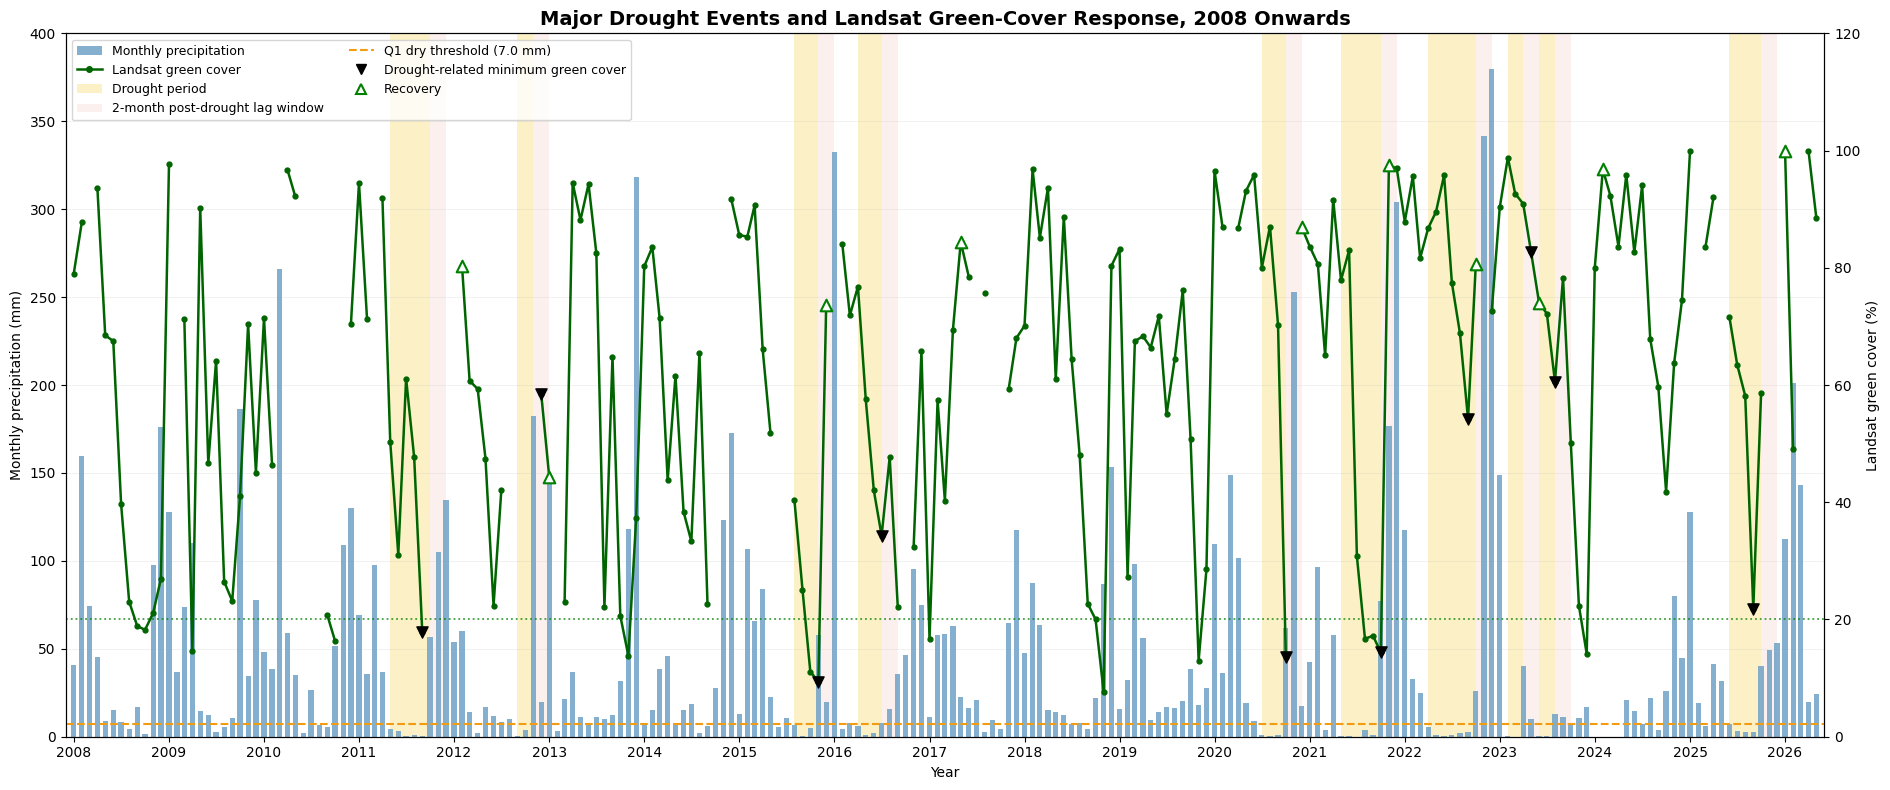

In [51]:
#plot major drought events with precipitation and landsat green cover
plot_data = landsat_timeline.loc[landsat_timeline["date"] >= plot_start_date].copy()
if drought_event_table.empty:
    print("No drought events available to plot.")
else:
    drought_plot_events = (drought_event_table.sort_values("drought_severity_deficit_mm", ascending=False)
        .head(10).sort_values("drought_start").reset_index(drop=True))
    drought_plot_events["plot_event"] = np.arange(1, len(drought_plot_events) + 1)
    fig, ax_precip = plt.subplots(figsize=(19, 8))
    #precipitation
    ax_precip.bar(plot_data["date"], plot_data["mean_precip_mm"],
        width=20, color="#77A6C9", alpha=0.90,
        zorder=2, label="Monthly precipitation")
    ax_precip.set_xlabel("Year")
    ax_precip.set_ylabel("Monthly precipitation (mm)")
    ax_precip.set_ylim(0, 400)
    ax_precip.grid(axis="y", linestyle="-", linewidth=0.6, alpha=0.20, zorder=1)

    #drought and lag windows
    for _, event in drought_plot_events.iterrows():
        start = event["drought_start"]
        end_display = event["drought_end"] + pd.DateOffset(months=1)
        lag_end = end_display + pd.DateOffset(months=best_lag)
        ax_precip.axvspan(
            start, end_display,
            color="#F7D96B", alpha=0.38, linewidth=0, zorder=0)
        ax_precip.axvspan(
            end_display, lag_end,
            color="#EFA49A", alpha=0.16, linewidth=0, zorder=0)
    ax_precip.axhline(
        drought_q1, color="#F39C12", linestyle="--", linewidth=1.5,
        label=f"Q1 dry threshold ({drought_q1:.1f} mm)", zorder=3)

    #landsat green cover
    ax_green = ax_precip.twinx()
    ax_green.plot(plot_data["date"], plot_data["green_cover_pct"],
        color="darkgreen", linewidth=1.8, marker="o", markersize=3.5,
        label="Landsat green cover", zorder=4)
    ax_green.axhline(20, color="green", linestyle=":", linewidth=1.3, alpha=0.75,
        label="20% green cover")
    ax_green.set_ylabel("Landsat green cover (%)")
    ax_green.set_ylim(0, 120)

    #minimum and recovery points
    for _, event in drought_plot_events.iterrows():
        if pd.notna(event["minimum_green_date"]):
            ax_green.scatter(
                event["minimum_green_date"], event["minimum_green_pct"],
                marker="v", s=65, color="black", edgecolor="black", zorder=6)
        if pd.notna(event["recovery_date"]):
            recovery_value = plot_data.loc[
                plot_data["date"].eq(event["recovery_date"]), "green_cover_pct"]
            if not recovery_value.empty:
                ax_green.scatter(
                    event["recovery_date"], recovery_value.iloc[0],
                    marker="^", s=70, facecolors="white",
                    edgecolors="green", linewidth=1.5, zorder=6)

    ax_precip.xaxis.set_major_locator(mdates.YearLocator(1))
    ax_precip.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax_precip.set_xlim(plot_data["date"].min() - pd.DateOffset(months=1),
        plot_data["date"].max() + pd.DateOffset(months=1))
    plt.xticks(rotation=45, ha="right")

    #legend
    legend_items = [Patch(facecolor="#77A6C9", alpha=0.90, label="Monthly precipitation"),
        Line2D([0], [0], color="darkgreen", linewidth=1.8,
               marker="o", markersize=4, label="Landsat green cover"),
        Patch(facecolor="#F7D96B", alpha=0.38, label="Drought period"),
        Patch(facecolor="#EFA49A", alpha=0.16,
              label=f"{best_lag}-month post-drought lag window"),
        Line2D([0], [0], color="#F39C12", linestyle="--",
               linewidth=1.5, label=f"Q1 dry threshold ({drought_q1:.1f} mm)"),
        Line2D([0], [0], marker="v", color="black", linestyle="None",
               markersize=7, label="Drought-related minimum green cover"),
        Line2D([0], [0], marker="^", markerfacecolor="white",
               markeredgecolor="green", markeredgewidth=1.5,
               linestyle="None", markersize=7, label="Recovery")]
    ax_precip.legend(handles=legend_items, loc="upper left",
        ncol=2, fontsize=9, frameon=True)
    ax_precip.set_title(
        "Major Drought Events and Landsat Green-Cover Response, 2008 Onwards",
        fontsize=14, fontweight="bold")
    fig.tight_layout()
    plt.show()

In [52]:
#check landsat green-cover anomalies for 2022-2023
landsat_check = (calendar_df[["date", "green_cover_pct", "mean_precip_mm"]]
    .sort_values("date").copy())
landsat_check["year"] = landsat_check["date"].dt.year
landsat_check["month"] = landsat_check["date"].dt.month
landsat_check["month_name"] = landsat_check["date"].dt.strftime("%b")
monthly_green_climatology = (landsat_check.dropna(subset=["green_cover_pct"]).groupby("month")
    .agg(climatology_mean_green=("green_cover_pct", "mean"),
        climatology_median_green=("green_cover_pct", "median"),
        climatology_std_green=("green_cover_pct", "std"),
        climatology_n=("green_cover_pct", "count"),).reset_index())
landsat_check = landsat_check.merge(monthly_green_climatology,on="month",how="left",)
landsat_check["green_anomaly_pct_points"] = (landsat_check["green_cover_pct"] - landsat_check["climatology_mean_green"])
landsat_check["green_zscore"] = (landsat_check["green_anomaly_pct_points"] / landsat_check["climatology_std_green"])
landsat_check["monthly_change_pct_points"] = (landsat_check["green_cover_pct"].diff())
check_2022_2023 = landsat_check.loc[
    landsat_check["year"].between(2022, 2023),
        ["date",
        "year",
        "month_name",
        "green_cover_pct",
        "mean_precip_mm",
        "climatology_mean_green",
        "green_anomaly_pct_points",
        "green_zscore",
        "monthly_change_pct_points",],].copy()

check_2022_2023["possible_anomaly"] = (
    check_2022_2023["green_zscore"].abs().ge(2)
    | check_2022_2023["monthly_change_pct_points"].abs().ge(30))

numeric_columns = ["green_cover_pct",
    "mean_precip_mm",
    "climatology_mean_green",
    "green_anomaly_pct_points",
    "green_zscore",
    "monthly_change_pct_points",]
check_2022_2023[numeric_columns] = check_2022_2023[numeric_columns].round(2)
print("Landsat green cover: 2022-2023")
display(check_2022_2023)
print("Possible anomalies only")
display(check_2022_2023.loc[check_2022_2023["possible_anomaly"]])

Landsat green cover: 2022-2023


,date,year,month_name,green_cover_pct,mean_precip_mm,climatology_mean_green,green_anomaly_pct_points,green_zscore,monthly_change_pct_points,possible_anomaly
228,2022-01-01,2022,Jan,87.89,117.30,75.40,12.49,0.54,-9.09,False
229,2022-02-01,2022,Feb,95.60,32.80,77.29,18.31,0.90,7.71,False
230,2022-03-01,2022,Mar,81.65,24.60,71.86,9.79,0.44,-13.96,False
231,2022-04-01,2022,Apr,86.77,5.40,79.69,7.09,0.35,5.13,False
232,2022-05-01,2022,May,89.55,0.80,75.76,13.79,0.83,2.78,False
233,2022-06-01,2022,Jun,95.79,0.33,70.81,24.98,1.07,6.23,False
234,2022-07-01,2022,Jul,77.42,0.80,63.37,14.04,0.66,-18.37,False
235,2022-08-01,2022,Aug,68.82,2.33,50.16,18.66,0.91,-8.59,False
236,2022-09-01,2022,Sep,54.22,2.60,38.56,15.66,0.72,-14.60,False
237,2022-10-01,2022,Oct,80.72,26.20,31.45,49.26,2.43,26.49,True


Possible anomalies only


,date,year,month_name,green_cover_pct,mean_precip_mm,climatology_mean_green,green_anomaly_pct_points,green_zscore,monthly_change_pct_points,possible_anomaly
237,2022-10-01,2022,Oct,80.72,26.2,31.45,49.26,2.43,26.49,True
